# Perbandingan dengan Patokan Naif

Notebook ujian (`2802453572_NO1.ipynb`) membandingkan model LSTM final dengan baseline LSTM, tetapi belum dengan patokan paling sederhana untuk harga saham: **harga besok sama dengan harga hari ini**. Model final memprediksi selisih terhadap harga terakhir di jendela input, jadi patokan ini perlu untuk melihat apakah LSTM benar-benar menambah informasi.

Notebook ini tidak membutuhkan TensorFlow. Data dibagi dengan cara yang persis sama seperti notebook ujian: satu tahun terakhir untuk uji, dengan 5 hari terakhir data latih sebagai konteks jendela pertama.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

WINDOW = 5  # sama dengan notebook ujian


def load_stock(path):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    return df.sort_values("Date").reset_index(drop=True)[["Date", "Close"]]


def data_uji(df):
    """Target uji dan harga terakhir di setiap jendela, persis seperti prepare_data di notebook ujian."""
    cutoff = df["Date"].max() - pd.DateOffset(years=1)
    train, test = df[df["Date"] <= cutoff], df[df["Date"] > cutoff]
    konteks = pd.concat([train.tail(WINDOW), test], ignore_index=True)["Close"].to_numpy()
    jendela = np.array([konteks[i:i + WINDOW] for i in range(len(konteks) - WINDOW)])
    return konteks[WINDOW:], jendela, test["Date"].to_numpy()


def metrik(y, pred):
    return {"RMSE": np.sqrt(mean_squared_error(y, pred)),
            "MAE": mean_absolute_error(y, pred),
            "MAPE (%)": mean_absolute_percentage_error(y, pred) * 100}

## Hasil

Dua patokan tanpa model:

- **Harga besok = harga hari ini**: prediksinya harga terakhir di jendela input.
- **Rata-rata 5 hari**: rata-rata harga di jendela input.

Angka LSTM disalin dari output sel evaluasi di notebook ujian, karena notebook itu dijalankan di Google Colab dengan TensorFlow.

In [2]:
# Output sel evaluasi (bagian 1d) di 2802453572_NO1.ipynb
LSTM = {
    ("AAPL", "LSTM baseline (target harga)"): {"RMSE": 18.8529, "MAE": 12.4449, "MAPE (%)": 4.6568},
    ("AAPL", "LSTM final (target selisih)"):  {"RMSE": 6.3163, "MAE": 3.9364, "MAPE (%)": 1.6092},
    ("AMD", "LSTM baseline (target harga)"):  {"RMSE": 1.4360, "MAE": 0.9429, "MAPE (%)": 2.5140},
    ("AMD", "LSTM final (target selisih)"):   {"RMSE": 1.3767, "MAE": 0.9196, "MAPE (%)": 2.4557},
}

baris = dict(LSTM)
uji = {}
for t in ["AAPL", "AMD"]:
    y, jendela, tanggal = data_uji(load_stock(f"{t}.csv"))
    uji[t] = (y, jendela, tanggal)
    baris[(t, "Patokan: harga besok = hari ini")] = metrik(y, jendela[:, -1])
    baris[(t, "Patokan: rata-rata 5 hari")] = metrik(y, jendela.mean(axis=1))
    print(f"{t}: {len(y)} hari uji, {pd.Timestamp(tanggal[0]).date()} s.d. {pd.Timestamp(tanggal[-1]).date()}")

hasil = pd.DataFrame(baris).T.sort_index(level=0, sort_remaining=False)
hasil.round(3)

AAPL: 253 hari uji, 2019-04-02 s.d. 2020-04-01
AMD: 253 hari uji, 2019-04-02 s.d. 2020-04-01


RMSE     MAE  MAPE (%)
AAPL LSTM baseline (target harga)     18.853  12.445     4.657
     LSTM final (target selisih)       6.316   3.936     1.609
     Patokan: harga besok = hari ini   6.294   3.841     1.573
     Patokan: rata-rata 5 hari         7.341   5.151     2.145
AMD  LSTM baseline (target harga)      1.436   0.943     2.514
     LSTM final (target selisih)       1.377   0.920     2.456
     Patokan: harga besok = hari ini   1.376   0.911     2.441
     Patokan: rata-rata 5 hari         1.891   1.315     3.491

In [3]:
# Seberapa jauh LSTM final dari patokan harga-kemarin
for t in ["AAPL", "AMD"]:
    final = hasil.loc[(t, "LSTM final (target selisih)")]
    naif = hasil.loc[(t, "Patokan: harga besok = hari ini")]
    awal = hasil.loc[(t, "LSTM baseline (target harga)")]
    print(f"{t}: LSTM final dibanding patokan -> RMSE {final['RMSE'] / naif['RMSE'] - 1:+.1%}, "
          f"MAE {final['MAE'] / naif['MAE'] - 1:+.1%} | baseline LSTM {awal['RMSE'] / naif['RMSE']:.1f}x RMSE patokan")

AAPL: LSTM final dibanding patokan -> RMSE +0.4%, MAE +2.5% | baseline LSTM 3.0x RMSE patokan
AMD: LSTM final dibanding patokan -> RMSE +0.0%, MAE +0.9% | baseline LSTM 1.0x RMSE patokan


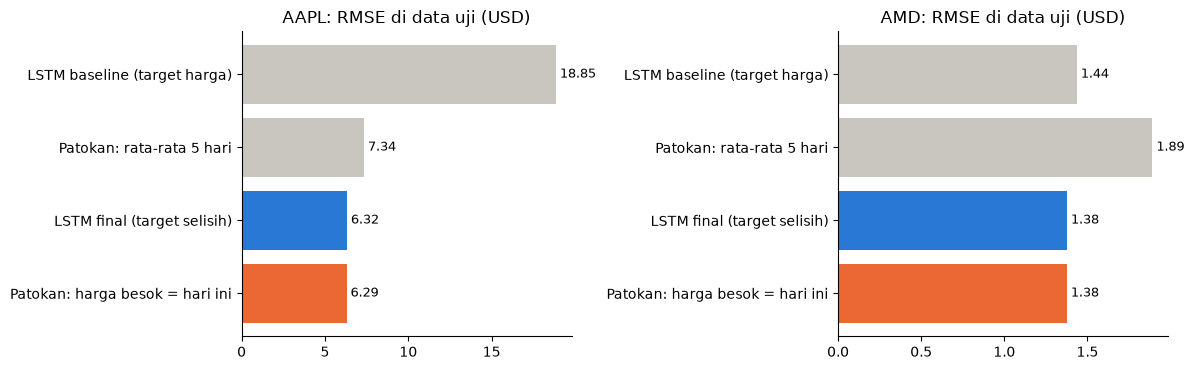

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
urutan = ["LSTM baseline (target harga)", "Patokan: rata-rata 5 hari", "LSTM final (target selisih)", "Patokan: harga besok = hari ini"]
warna = ["#c8c6bf", "#c8c6bf", "#2a78d6", "#eb6834"]
for ax, t in zip(axes, ["AAPL", "AMD"]):
    nilai = hasil.loc[t].loc[urutan, "RMSE"]
    ax.barh(range(len(urutan)), nilai.values, color=warna)
    ax.set_yticks(range(len(urutan)), urutan)
    for i, v in enumerate(nilai.values):
        ax.text(v, i, f" {v:.2f}", va="center", fontsize=9)
    ax.set_title(f"{t}: RMSE di data uji (USD)")
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Kesimpulan

- **LSTM final tidak lebih baik dari patokan harga-kemarin.** Selisihnya sangat kecil, dan di MAE LSTM final sedikit lebih buruk di kedua saham. Model final praktis mempelajari selisih yang hampir nol, sehingga prediksinya hampir sama dengan harga terakhir.
- **Baseline LSTM jauh lebih buruk dari patokan** (RMSE AAPL sekitar tiga kali lipat). Jadi penurunan RMSE AAPL dari 18,85 ke 6,32 di notebook ujian sebenarnya adalah model yang kembali ke level patokan, bukan model yang mengalahkan patokan.
- Hasil ini sesuai sifat *random walk* harga saham: harga besok tidak bisa ditebak lebih baik dari harga hari ini hanya dengan melihat lima harga terakhir.

Pelajarannya: model deret waktu harus selalu dibandingkan dengan patokan naif. Tanpa pembanding itu, penurunan error 66% terlihat seperti keberhasilan besar. Untuk benar-benar mengalahkan patokan dibutuhkan informasi lain di luar harga penutupan, misalnya volume, harga saham lain, atau berita.